In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT = Path(
    "/Users/mixednutgiftpack/Documents/CASA/OD2017_2023"
)

OUTPUT = PROJECT / "outputs"
FIGURES = PROJECT / "figs"

FIGURES.mkdir(
    parents=True,
    exist_ok=True,
)


CLASS_ORDER = [
    "A",
    "B1",
    "B2",
    "C1",
    "C2",
    "D–E",
]


# Publication palette sampled from the reference screenshot
PUB_CLASS_COLOURS = {
    "A": "#551C69",
    "B1": "#524D8E",
    "B2": "#407697",
    "C1": "#339995",
    "C2": "#42BB84",
    "D–E": "#84D45F",
}


# Colours for the stacked population-location panel
RHYTHM_COLOURS = {
    "home_no_trip": "#8FBFA9",
    "home_mobile": "#DCE8E3",
    "away": "#90A5B7",
    "transit": "#D3DE9C",
}


INK = "#3A3F42"
INK_LIGHT = "#6B7075"


print(f"Project: {PROJECT}")
print(f"Figure output: {FIGURES}")

Project: /Users/mixednutgiftpack/Documents/CASA/OD2017_2023
Figure output: /Users/mixednutgiftpack/Documents/CASA/OD2017_2023/figs


In [2]:
persons = pd.read_parquet(
    OUTPUT / "persons_2023.parquet"
)

person_hours = pd.read_parquet(
    OUTPUT / "person_hours_2023.parquet"
)


required_person_columns = {
    "mobile",
    "fe_pess",
}

required_hour_columns = {
    "hour",
    "home",
    "away",
    "transit",
    "mobile",
    "fe_pess",
    "class6",
}


missing_person_columns = (
    required_person_columns
    - set(persons.columns)
)

missing_hour_columns = (
    required_hour_columns
    - set(person_hours.columns)
)


if missing_person_columns:
    raise KeyError(
        "Missing columns in persons_2023.parquet: "
        f"{sorted(missing_person_columns)}"
    )

if missing_hour_columns:
    raise KeyError(
        "Missing columns in person_hours_2023.parquet: "
        f"{sorted(missing_hour_columns)}"
    )


print(f"Adults: {len(persons):,}")
print(f"Person-hours: {len(person_hours):,}")

Adults: 66,517
Person-hours: 1,596,408


In [3]:
# Work on a copy so that the loaded data are not modified
rhythm_data = person_hours.copy()

rhythm_data["home_no_trip"] = np.where(
    ~rhythm_data["mobile"],
    rhythm_data["home"],
    0,
)

rhythm_data["home_mobile"] = np.where(
    rhythm_data["mobile"],
    rhythm_data["home"],
    0,
)


RHYTHM_CATEGORIES = [
    "home_no_trip",
    "home_mobile",
    "away",
    "transit",
]


for category in RHYTHM_CATEGORIES:
    rhythm_data[f"weighted_{category}"] = (
        rhythm_data[category]
        * rhythm_data["fe_pess"]
    )


weighted_minutes_per_hour = (
    persons["fe_pess"].sum()
    * 60
)


population_rhythm = (
    rhythm_data
    .groupby("hour")[
        [
            f"weighted_{category}"
            for category in RHYTHM_CATEGORIES
        ]
    ]
    .sum()
    .reindex(range(24))
)


population_rhythm.columns = RHYTHM_CATEGORIES


population_rhythm = (
    population_rhythm
    / weighted_minutes_per_hour
)


population_rhythm["total"] = (
    population_rhythm[
        RHYTHM_CATEGORIES
    ]
    .sum(axis=1)
)


# Check that the four states sum to one
invalid_totals = (
    population_rhythm["total"]
    .sub(1)
    .abs()
    .gt(1e-9)
)

if invalid_totals.any():
    raise ValueError(
        "Some hourly population states do not sum to 100%."
    )



weighted_no_trip_share = (
    persons.loc[
        ~persons["mobile"],
        "fe_pess",
    ].sum()
    / persons["fe_pess"].sum()
)


class_home_rhythm = (
    rhythm_data
    .assign(
        weighted_home_minutes=(
            rhythm_data["home"]
            * rhythm_data["fe_pess"]
        ),
        weighted_total_minutes=(
            60
            * rhythm_data["fe_pess"]
        ),
    )
    .groupby(
        [
            "class6",
            "hour",
        ],
        observed=True,
    )
    .agg(
        home_minutes=(
            "weighted_home_minutes",
            "sum",
        ),
        total_minutes=(
            "weighted_total_minutes",
            "sum",
        ),
    )
    .reset_index()
)


class_home_rhythm["home_share"] = (
    class_home_rhythm["home_minutes"]
    / class_home_rhythm["total_minutes"]
)


class_home_wide = (
    class_home_rhythm
    .pivot(
        index="hour",
        columns="class6",
        values="home_share",
    )
    .reindex(
        index=range(24),
        columns=CLASS_ORDER,
    )
)


RHYTHM_LABELS = {
    "home_no_trip": (
        "At home — no recorded trips "
        f"({weighted_no_trip_share:.1%})"
    ),
    "home_mobile": "At home — mobile adults",
    "away": "Elsewhere in the region",
    "transit": "In transport",
}


# Display the survey day from 04:00 to 03:00
HOUR_ORDER = (
    list(range(4, 24))
    + list(range(0, 4))
)

HOUR_LABELS = [
    f"{hour:02d}"
    for hour in HOUR_ORDER
]


print(
    "Weighted adults without recorded trips: "
    f"{weighted_no_trip_share:.1%}"
)

display(
    (
        population_rhythm[
            RHYTHM_CATEGORIES
        ]
        * 100
    ).round(1)
)

display(
    (
        class_home_wide
        * 100
    ).round(1)
)

Weighted adults without recorded trips: 40.5%


,home_no_trip,home_mobile,away,transit
hour,,,,
0,40.5,58.1,1.3,0.2
1,40.5,58.3,1.2,0.1
2,40.5,58.4,1.0,0.1
3,40.5,58.5,1.0,0.1
4,40.5,57.3,1.0,1.2
5,40.5,53.7,2.0,3.8
6,40.5,44.9,5.6,9.0
7,40.5,34.1,15.3,10.1
8,40.5,27.3,26.5,5.8


class6,A,B1,B2,C1,C2,D–E
hour,,,,,,
0,98.9,98.8,98.6,98.2,98.5,99.1
1,99.1,99.1,98.9,98.4,98.7,99.2
2,99.2,99.1,99.0,98.6,98.8,99.3
3,99.3,99.4,99.0,98.7,98.9,99.3
4,99.1,99.0,98.2,97.4,97.2,97.7
5,97.8,97.0,95.1,93.4,92.7,94.2
6,90.4,88.1,86.5,83.9,83.7,87.9
7,77.6,75.7,73.9,72.8,74.6,80.3
8,67.3,66.1,65.5,66.4,69.7,75.9


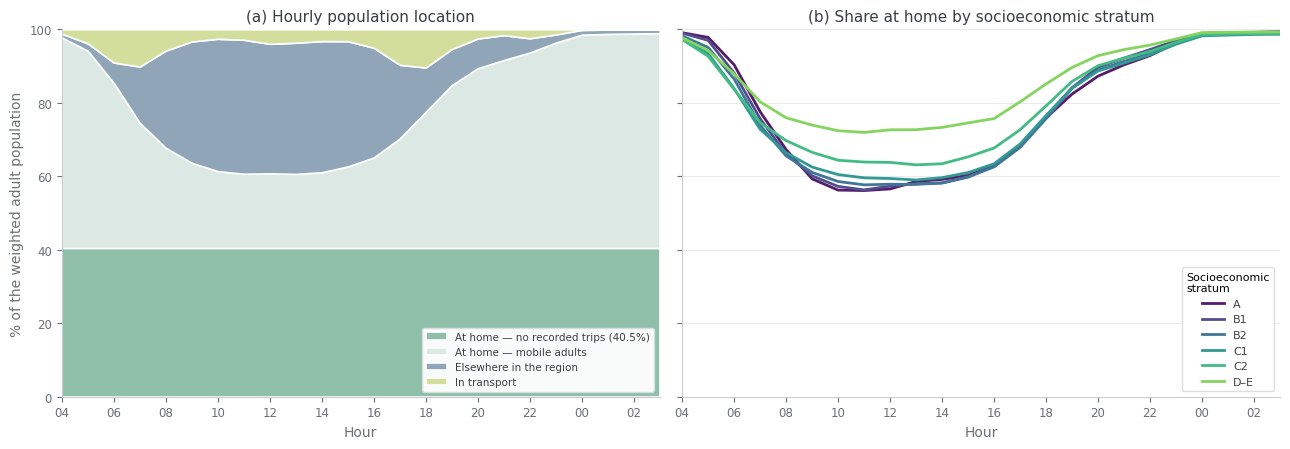

Saved to: /Users/mixednutgiftpack/Documents/CASA/OD2017_2023/figs/fig_rhythm_pub_2023.png


In [4]:
fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(13, 4.6),
    sharey=True,
)

fig.patch.set_facecolor("white")

panel_a = population_rhythm.loc[
    HOUR_ORDER,
    RHYTHM_CATEGORIES,
]


axes[0].stackplot(
    range(24),
    panel_a.T.to_numpy() * 100,
    labels=[
        RHYTHM_LABELS[category]
        for category in RHYTHM_CATEGORIES
    ],
    colors=[
        RHYTHM_COLOURS[category]
        for category in RHYTHM_CATEGORIES
    ],
    edgecolor="white",
    linewidth=1.2,
)


axes[0].set_title(
    "(a) Hourly population location",
    color=INK,
    fontsize=11,
)


axes[0].set_ylabel(
    "% of the weighted adult population",
    color=INK_LIGHT,
)


axes[0].legend(
    loc="lower right",
    fontsize=7.5,
    frameon=True,
    framealpha=0.95,
    edgecolor="#D9DCDF",
    labelcolor=INK,
)


for class_label in CLASS_ORDER:
    class_curve = (
        class_home_wide
        .loc[
            HOUR_ORDER,
            class_label,
        ]
        .to_numpy()
        * 100
    )

    axes[1].plot(
        range(24),
        class_curve,
        color=PUB_CLASS_COLOURS[class_label],
        linewidth=2,
        label=class_label,
    )


axes[1].set_title(
    "(b) Share at home by socioeconomic stratum",
    color=INK,
    fontsize=11,
)


axes[1].legend(
    title="Socioeconomic\nstratum",
    loc="lower right",
    fontsize=8,
    title_fontsize=8,
    frameon=True,
    framealpha=0.95,
    edgecolor="#D9DCDF",
    labelcolor=INK,
)

tick_positions = list(
    range(0, 24, 2)
)

tick_labels = HOUR_LABELS[::2]


for ax in axes:
    ax.set_xticks(
        tick_positions
    )

    ax.set_xticklabels(
        tick_labels
    )

    ax.set_xlim(
        0,
        23,
    )

    ax.set_ylim(
        0,
        100,
    )

    ax.set_xlabel(
        "Hour",
        color=INK_LIGHT,
    )

    ax.tick_params(
        axis="both",
        colors=INK_LIGHT,
        labelsize=8.5,
    )

    ax.margins(x=0)

    ax.grid(
        axis="y",
        color="#E8EAEC",
        linewidth=0.7,
    )

    ax.set_axisbelow(True)

    for spine in [
        "top",
        "right",
    ]:
        ax.spines[
            spine
        ].set_visible(False)

    for spine in [
        "left",
        "bottom",
    ]:
        ax.spines[
            spine
        ].set_color("#C9CDD1")


fig.tight_layout()


figure_path = (
    FIGURES
    / "fig_rhythm_pub_2023.png"
)


fig.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
)


plt.show()

print(f"Saved to: {figure_path}")

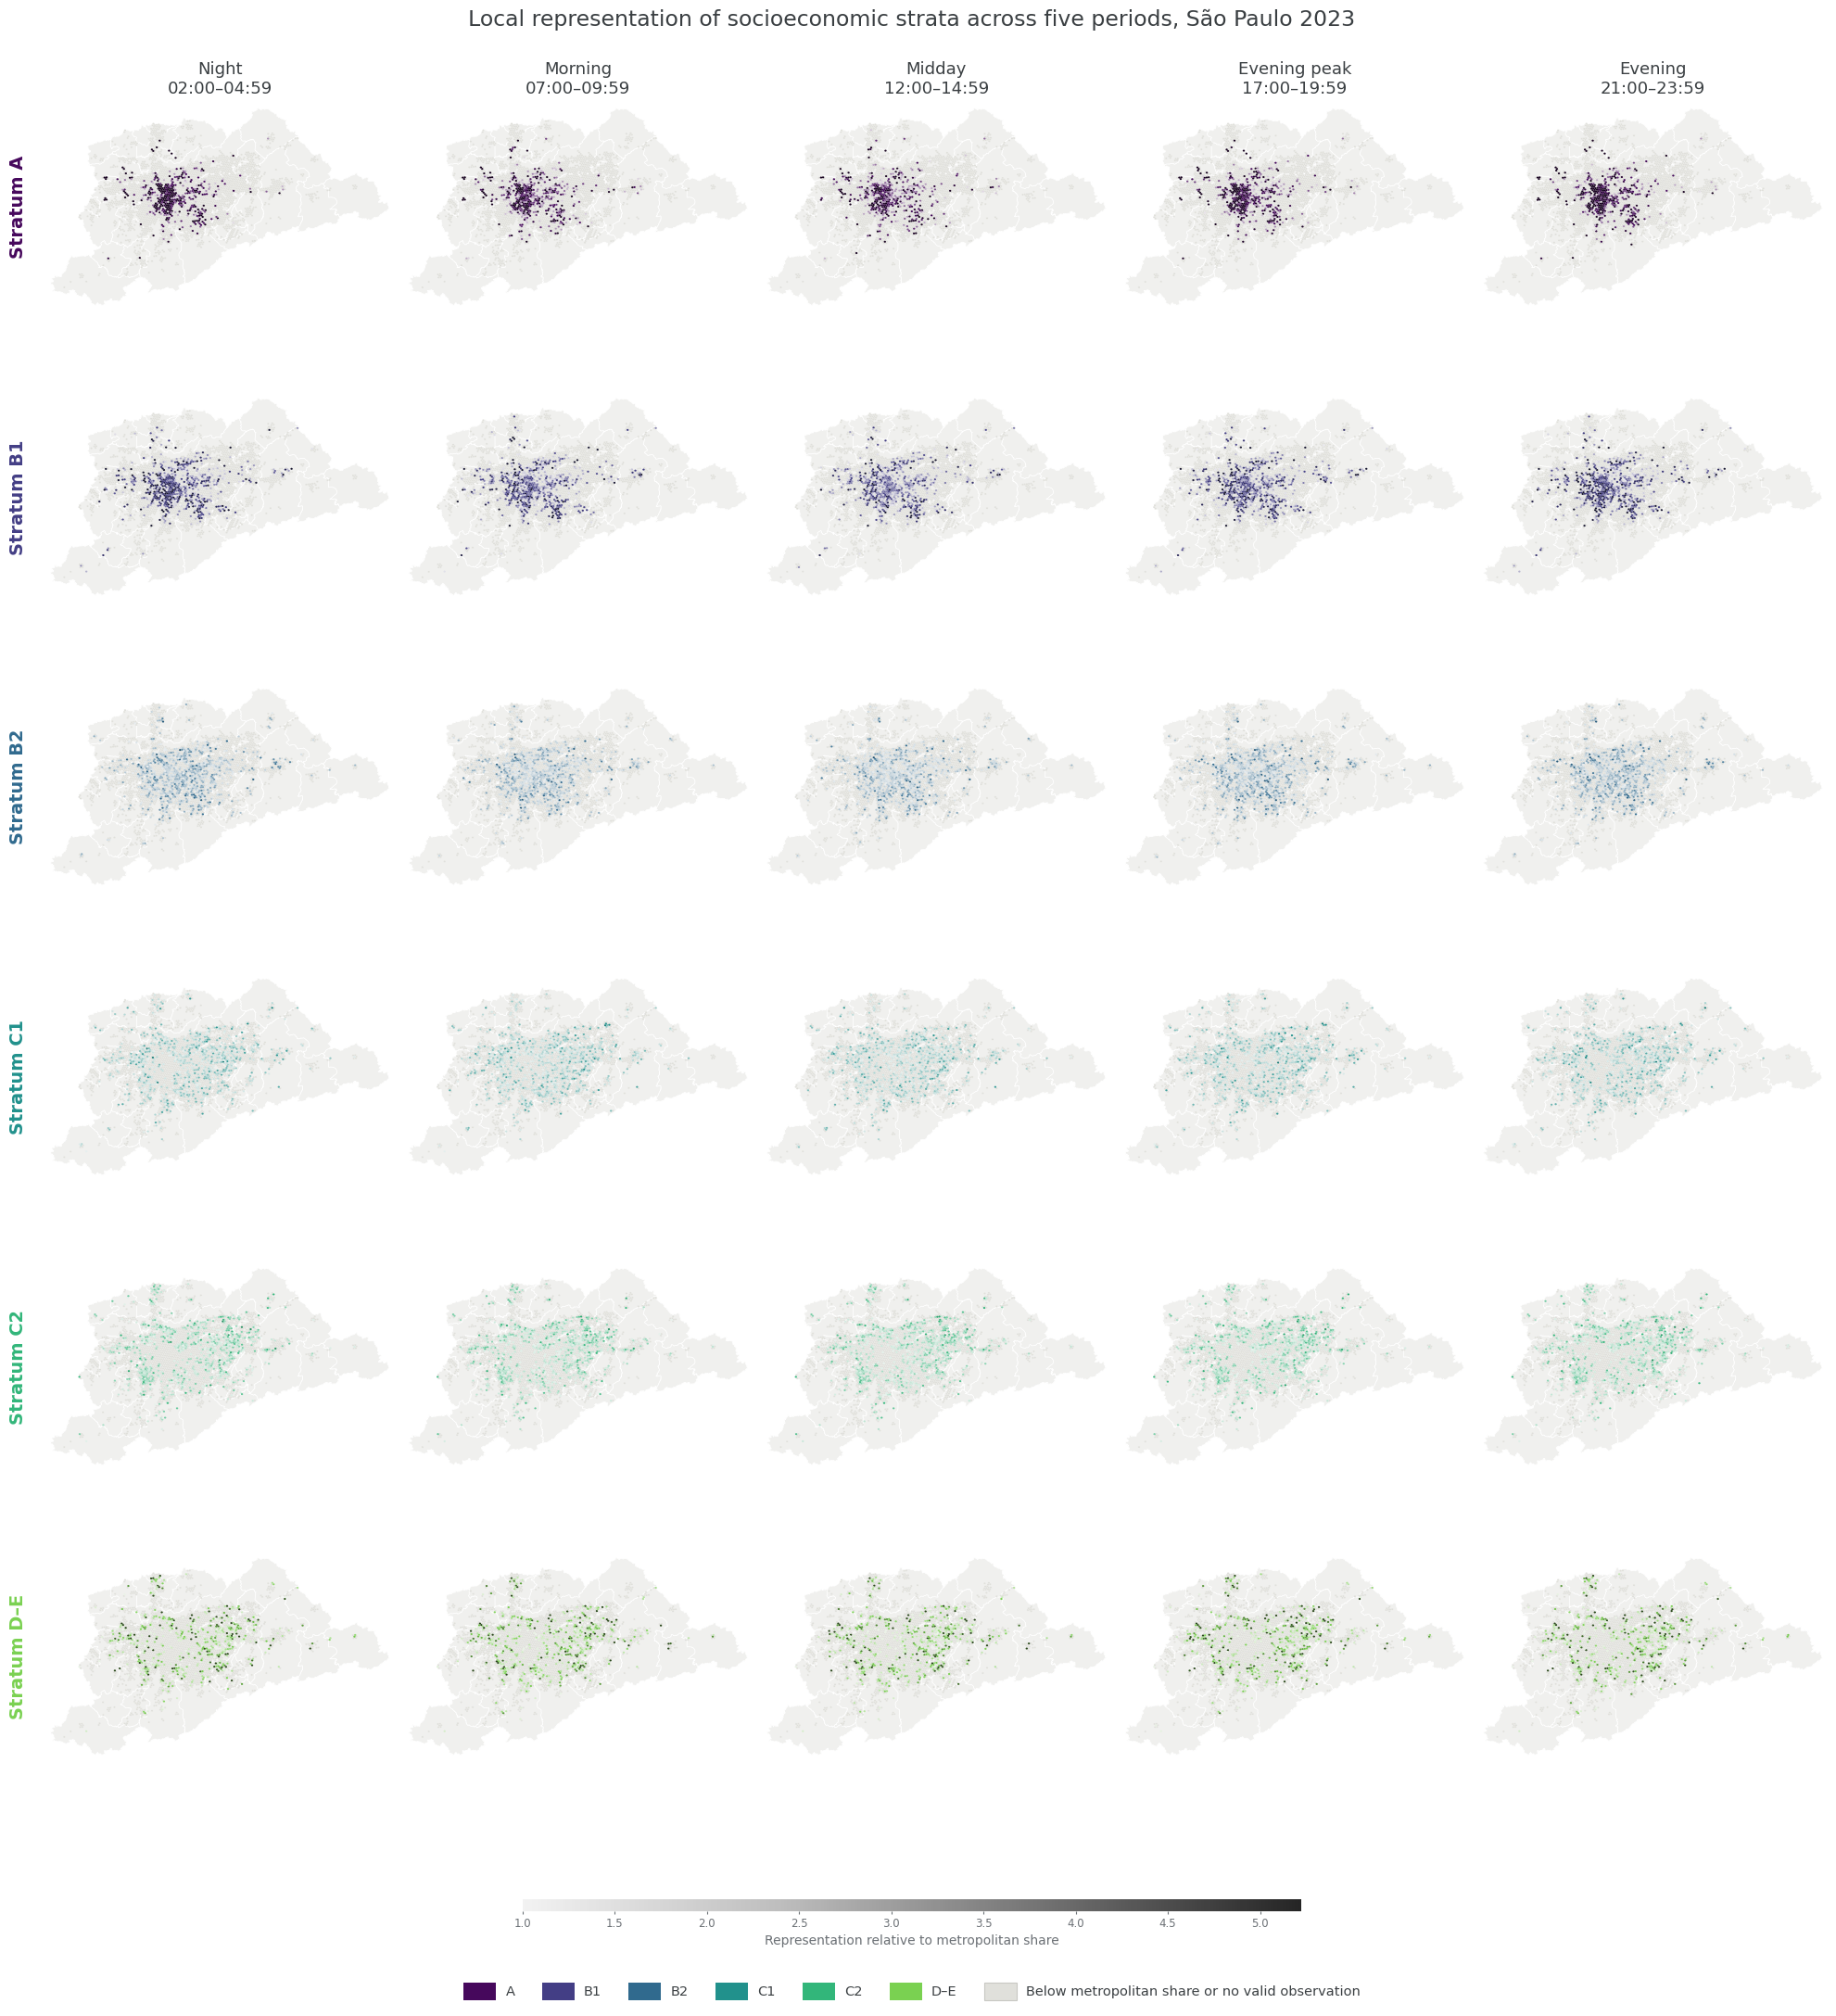

Saved figure: /Users/mixednutgiftpack/Documents/CASA/OD2017_2023/figs/pub_map.png


In [7]:
from pathlib import Path

import h3
import geopandas as gpd
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from matplotlib.collections import PolyCollection
from matplotlib.patches import Patch

PROJECT = Path(
    "/Users/mixednutgiftpack/Documents/CASA/OD2017_2023"
)
FIGURES = PROJECT / "figs"
SHAPES = PROJECT / "2023_OD/Shape"

FIGURES.mkdir(
    parents=True,
    exist_ok=True,
)

CLASS_ORDER = [
    "A",
    "B1",
    "B2",
    "C1",
    "C2",
    "D–E",
]

CLASS_COLOURS = {
    "A": "#46085C",
    "B1": "#433E85",
    "B2": "#306A8E",
    "C1": "#21918C",
    "C2": "#32B67A",
    "D–E": "#7AD151",
}

WINDOWS = {
    "night": [2, 3, 4],
    "morning": [7, 8, 9],
    "midday": [12, 13, 14],
    "pm_peak": [17, 18, 19],
    "evening": [21, 22, 23],
}

WINDOW_LABELS = {
    "night": "Night\n02:00–04:59",
    "morning": "Morning\n07:00–09:59",
    "midday": "Midday\n12:00–14:59",
    "pm_peak": "Evening peak\n17:00–19:59",
    "evening": "Evening\n21:00–23:59",
}

SUPPORT_MIN = 10
UNIVERSE_MIN = 3

INK = "#3A3F42"
INK_LIGHT = "#6B7075"
GREY_HEX = "#E0E0DB"


presence = pd.read_parquet(
    OUTPUT / "presence_hourly_2023.parquet"
)

municipalities = (
    gpd.read_file(
        SHAPES / "Municipios_2023.shp"
    )
    .to_crs(4326)
)

presence["class6"] = presence["class6"].replace(
    {
        "DE": "D–E",
        "D-E": "D–E",
    }
)

presence["population_contribution"] = (
    presence["weighted_minutes"] / 60
)

H3_UNIVERSE = (
    presence
    .groupby("hex")["id_pess"]
    .nunique()
    .loc[lambda x: x.ge(UNIVERSE_MIN)]
    .index
    .tolist()
)

if hasattr(h3, "cell_to_boundary"):
    cell_boundary = h3.cell_to_boundary
else:
    cell_boundary = h3.h3_to_geo_boundary


def h3_polygon(hex_id):
    return [
        (longitude, latitude)
        for latitude, longitude
        in cell_boundary(hex_id)
    ]


H3_POLYGONS = {
    hex_id: h3_polygon(hex_id)
    for hex_id in H3_UNIVERSE
}

min_x, min_y, max_x, max_y = (
    municipalities.total_bounds
)

X_LIMITS = (
    min_x - 0.02,
    max_x + 0.02,
)

Y_LIMITS = (
    min_y - 0.02,
    max_y + 0.02,
)

representation_surface = {}

for window, hours in WINDOWS.items():
    window_data = presence.loc[
        presence["hour"].isin(hours)
    ]

    class_population = (
        window_data
        .pivot_table(
            index="hex",
            columns="class6",
            values="population_contribution",
            aggfunc="sum",
            fill_value=0,
        )
        .reindex(
            columns=CLASS_ORDER,
            fill_value=0,
        )
    )

    total_population = class_population.sum(axis=1)

    metropolitan_share = (
        class_population.sum(axis=0)
        / class_population.to_numpy().sum()
    )

    supported_hexes = (
        window_data
        .groupby("hex")["id_pess"]
        .nunique()
        .loc[lambda x: x.ge(SUPPORT_MIN)]
        .index
    )

    for stratum in CLASS_ORDER:
        representation_surface[
            stratum,
            window,
        ] = (
            class_population[stratum]
            .div(total_population)
            .div(metropolitan_share[stratum])
            .reindex(supported_hexes)
        )


# Shared colour scale


def stratum_colourmap(base_colour):
    """Create a light-to-dark colour scale for one stratum."""
    base = np.array(
        mcolors.to_rgb(base_colour)
    )

    white = np.array(
        mcolors.to_rgb("#F7F7F7")
    )

    light = white + 0.08 * (base - white)
    dark = base * 0.35

    return mcolors.LinearSegmentedColormap.from_list(
        "stratum_ramp",
        [
            mcolors.to_hex(light),
            base_colour,
            mcolors.to_hex(dark),
        ],
    )


# Use one common scale across all strata and periods
all_representation_values = pd.concat(
    [
        values
        for values in representation_surface.values()
    ]
)

represented_values = all_representation_values.loc[
    all_representation_values.ge(1)
].dropna()

GLOBAL_NORM = mcolors.Normalize(
    vmin=1,
    vmax=max(
        1.01,
        represented_values.quantile(0.95),
    ),
)



def draw_map(
    ax,
    representation,
    colourmap,
):
    municipalities.plot(
        ax=ax,
        facecolor="#F0F0EE",
        edgecolor="white",
        linewidth=0.5,
        zorder=0,
    )

    represented = representation.loc[
        representation.ge(1)
    ].dropna()

    represented_hexes = set(
        represented.index
    )

    grey_hexes = [
        hex_id
        for hex_id in H3_UNIVERSE
        if hex_id not in represented_hexes
    ]

    ax.add_collection(
        PolyCollection(
            [
                H3_POLYGONS[hex_id]
                for hex_id in grey_hexes
            ],
            facecolor=GREY_HEX,
            edgecolor="white",
            linewidth=0.08,
            zorder=1,
        )
    )

    valid_hexes = [
        hex_id
        for hex_id in represented.index
        if hex_id in H3_POLYGONS
    ]

    ax.add_collection(
        PolyCollection(
            [
                H3_POLYGONS[hex_id]
                for hex_id in valid_hexes
            ],
            array=represented.loc[
                valid_hexes
            ].to_numpy(),
            cmap=colourmap,
            norm=GLOBAL_NORM,
            edgecolor="none",
            zorder=2,
        )
    )

    ax.set(
        xlim=X_LIMITS,
        ylim=Y_LIMITS,
        aspect="equal",
    )

    ax.set_axis_off()



fig, axes = plt.subplots(
    nrows=len(CLASS_ORDER),
    ncols=len(WINDOWS),
    figsize=(21, 22),
    facecolor="white",
)

for row, stratum in enumerate(CLASS_ORDER):
    colourmap = stratum_colourmap(
        CLASS_COLOURS[stratum]
    )

    for column, window in enumerate(WINDOWS):
        ax = axes[row, column]

        draw_map(
            ax,
            representation_surface[
                stratum,
                window,
            ],
            colourmap,
        )

        # Period labels above the first row
        if row == 0:
            ax.set_title(
                WINDOW_LABELS[window],
                color=INK,
                fontsize=13,
                pad=8,
            )

        # Stratum labels beside the first column
        if column == 0:
            ax.text(
                -0.08,
                0.5,
                f"Stratum {stratum}",
                transform=ax.transAxes,
                rotation=90,
                ha="center",
                va="center",
                color=CLASS_COLOURS[stratum],
                fontsize=14,
                fontweight="bold",
            )


fig.suptitle(
    (
        "Local representation of socioeconomic strata "
        "across five periods, São Paulo 2023"
    ),
    color=INK,
    fontsize=17,
    y=0.995,
)

# grey colour bar

grey_colourmap = mcolors.LinearSegmentedColormap.from_list(
    "representation_grey",
    [
        "#F2F2F2",
        "#BDBDBD",
        "#737373",
        "#252525",
    ],
)


colourbar_axis = fig.add_axes(
    [0.30, 0.062, 0.40, 0.006]
)

colourbar = fig.colorbar(
    plt.cm.ScalarMappable(
        cmap=grey_colourmap,
        norm=GLOBAL_NORM,
    ),
    cax=colourbar_axis,
    orientation="horizontal",
)

colourbar.set_label(
    "Representation relative to metropolitan share",
    color=INK_LIGHT,
    fontsize=10,
    labelpad=4,
)

colourbar.ax.tick_params(
    colors=INK_LIGHT,
    labelsize=8.5,
    length=2.5,
    pad=2,
)

colourbar.outline.set_visible(False)


# stratum colour blocks
stratum_handles = [
    Patch(
        facecolor=CLASS_COLOURS[stratum],
        edgecolor="none",
        label=stratum,
    )
    for stratum in CLASS_ORDER
]

grey_handle = Patch(
    facecolor=GREY_HEX,
    edgecolor="#C8C8C3",
    linewidth=0.8,
    label="Below metropolitan share or no valid observation",
)

fig.legend(
    handles=[
        *stratum_handles,
        grey_handle,
    ],
    loc="lower center",
    bbox_to_anchor=(0.5, 0.012),
    ncol=7,
    frameon=False,
    fontsize=10.5,
    labelcolor=INK,

    handlelength=2.4,
    handleheight=1.6,


    columnspacing=2.0,
    handletextpad=0.7,
    borderpad=0.5,
)


fig.subplots_adjust(
    left=0.055,
    right=0.97,
    top=0.965,
    bottom=0.12,
    wspace=0.03,
    hspace=0.06,
)


output_path = FIGURES / "pub_map.png"

fig.savefig(
    output_path,
    dpi=220,
    bbox_inches="tight",
    facecolor="white",
)

plt.show()

print(f"Saved figure: {output_path}")

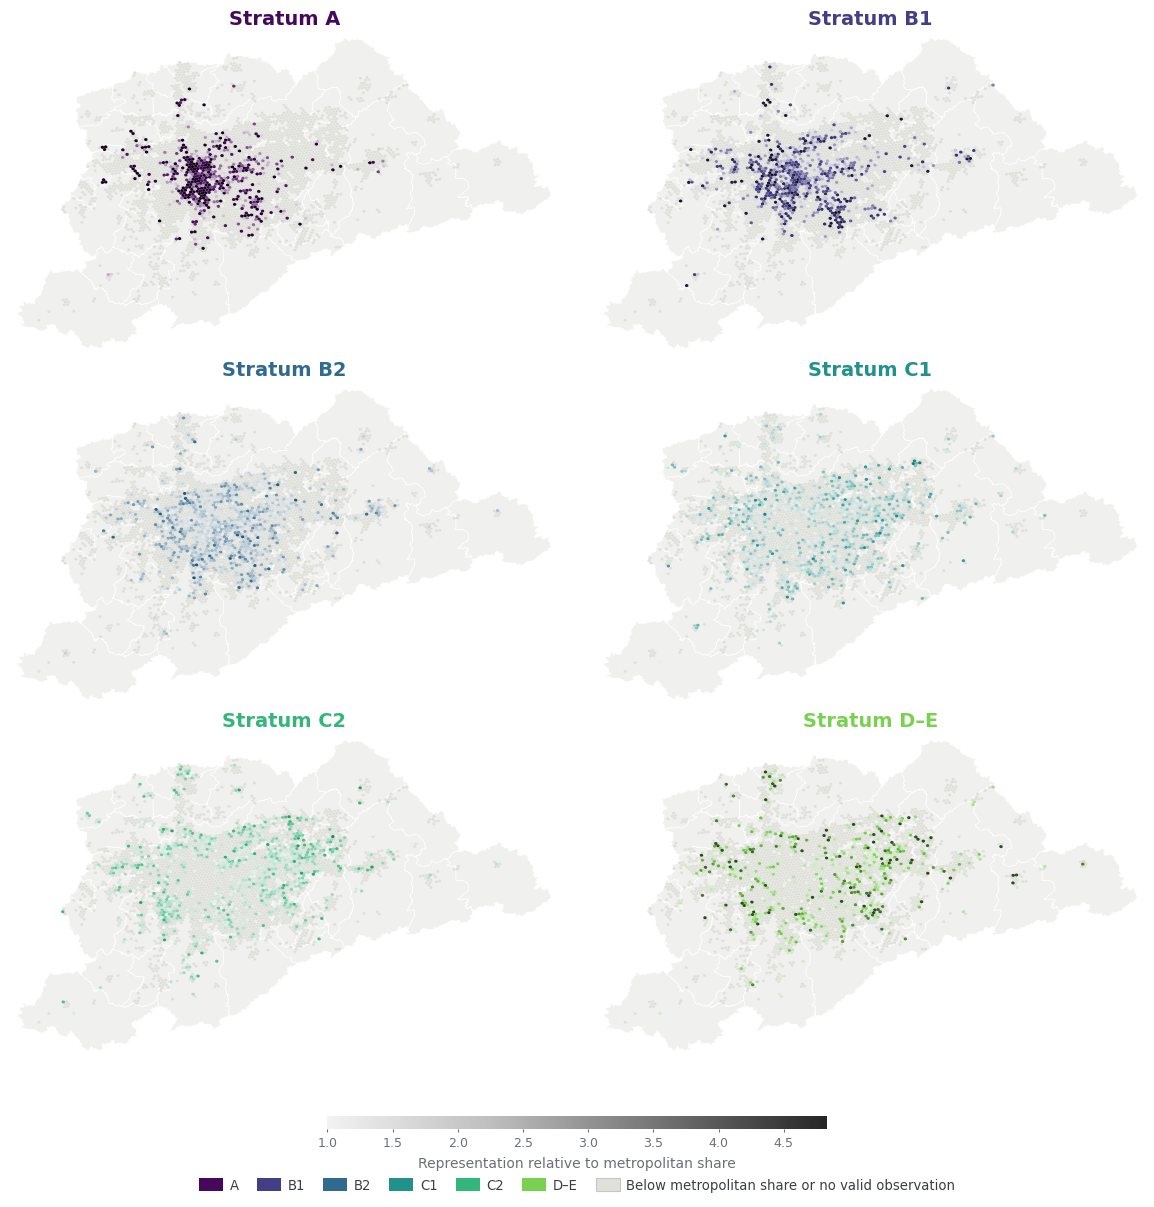

Saved figure: /Users/mixednutgiftpack/Documents/CASA/OD2017_2023/figs/morning_representation_six_strata_2023.png


In [6]:


PROJECT = Path(
    "/Users/mixednutgiftpack/Documents/CASA/OD2017_2023"
)

OUTPUT = PROJECT / "outputs"
FIGURES = PROJECT / "figs"
SHAPES = PROJECT / "2023_OD/Shape"

FIGURES.mkdir(
    parents=True,
    exist_ok=True,
)

CLASS_ORDER = [
    "A",
    "B1",
    "B2",
    "C1",
    "C2",
    "D–E",
]

CLASS_COLOURS = {
    "A": "#46085C",
    "B1": "#433E85",
    "B2": "#306A8E",
    "C1": "#21918C",
    "C2": "#32B67A",
    "D–E": "#7AD151",
}

# Selected morning travel period
MORNING_HOURS = [7, 8, 9]

SUPPORT_MIN = 10
UNIVERSE_MIN = 3

INK = "#3A3F42"
INK_LIGHT = "#6B7075"
GREY_HEX = "#E0E0DB"

presence = pd.read_parquet(
    OUTPUT / "presence_hourly_2023.parquet"
)

municipalities = (
    gpd.read_file(
        SHAPES / "Municipios_2023.shp"
    )
    .to_crs(4326)
)

presence["class6"] = presence["class6"].replace(
    {
        "DE": "D–E",
        "D-E": "D–E",
    }
)

presence["population_contribution"] = (
    presence["weighted_minutes"] / 60
)


H3_UNIVERSE = (
    presence
    .groupby("hex")["id_pess"]
    .nunique()
    .loc[lambda values: values.ge(UNIVERSE_MIN)]
    .index
    .tolist()
)

if hasattr(h3, "cell_to_boundary"):
    cell_boundary = h3.cell_to_boundary
else:
    cell_boundary = h3.h3_to_geo_boundary


def h3_polygon(hex_id):
    """Convert an H3 cell into matplotlib polygon coordinates."""
    return [
        (longitude, latitude)
        for latitude, longitude
        in cell_boundary(hex_id)
    ]


H3_POLYGONS = {
    hex_id: h3_polygon(hex_id)
    for hex_id in H3_UNIVERSE
}



min_x, min_y, max_x, max_y = (
    municipalities.total_bounds
)

X_LIMITS = (
    min_x - 0.02,
    max_x + 0.02,
)

Y_LIMITS = (
    min_y - 0.02,
    max_y + 0.02,
)

morning_data = presence.loc[
    presence["hour"].isin(MORNING_HOURS)
].copy()

class_population = (
    morning_data
    .pivot_table(
        index="hex",
        columns="class6",
        values="population_contribution",
        aggfunc="sum",
        fill_value=0,
    )
    .reindex(
        columns=CLASS_ORDER,
        fill_value=0,
    )
)

total_population = class_population.sum(axis=1)

metropolitan_share = (
    class_population.sum(axis=0)
    / class_population.to_numpy().sum()
)

supported_hexes = (
    morning_data
    .groupby("hex")["id_pess"]
    .nunique()
    .loc[lambda values: values.ge(SUPPORT_MIN)]
    .index
)

morning_representation = {}

for stratum in CLASS_ORDER:
    morning_representation[stratum] = (
        class_population[stratum]
        .div(total_population)
        .div(metropolitan_share[stratum])
        .reindex(supported_hexes)
    )


# Shared colour scale
def stratum_colourmap(base_colour):
    """Create a light-to-dark colour scale for one stratum."""
    base = np.array(
        mcolors.to_rgb(base_colour)
    )

    white = np.array(
        mcolors.to_rgb("#F7F7F7")
    )

    light = white + 0.08 * (base - white)
    dark = base * 0.35

    return mcolors.LinearSegmentedColormap.from_list(
        "stratum_ramp",
        [
            mcolors.to_hex(light),
            base_colour,
            mcolors.to_hex(dark),
        ],
    )


all_morning_values = pd.concat(
    morning_representation.values()
)

represented_values = (
    all_morning_values
    .loc[all_morning_values.ge(1)]
    .dropna()
)

GLOBAL_NORM = mcolors.Normalize(
    vmin=1,
    vmax=max(
        1.01,
        represented_values.quantile(0.95),
    ),
)

# Map-drawing function
def draw_map(
    ax,
    representation,
    colourmap,
):
    municipalities.plot(
        ax=ax,
        facecolor="#F0F0EE",
        edgecolor="white",
        linewidth=0.5,
        zorder=0,
    )

    represented = (
        representation
        .loc[representation.ge(1)]
        .dropna()
    )

    represented_hexes = set(
        represented.index
    )

    grey_hexes = [
        hex_id
        for hex_id in H3_UNIVERSE
        if hex_id not in represented_hexes
    ]

    ax.add_collection(
        PolyCollection(
            [
                H3_POLYGONS[hex_id]
                for hex_id in grey_hexes
            ],
            facecolor=GREY_HEX,
            edgecolor="white",
            linewidth=0.08,
            zorder=1,
        )
    )

    valid_hexes = [
        hex_id
        for hex_id in represented.index
        if hex_id in H3_POLYGONS
    ]

    ax.add_collection(
        PolyCollection(
            [
                H3_POLYGONS[hex_id]
                for hex_id in valid_hexes
            ],
            array=represented.loc[
                valid_hexes
            ].to_numpy(),
            cmap=colourmap,
            norm=GLOBAL_NORM,
            edgecolor="none",
            zorder=2,
        )
    )

    ax.set(
        xlim=X_LIMITS,
        ylim=Y_LIMITS,
        aspect="equal",
    )

    ax.set_axis_off()


fig, axes = plt.subplots(
    nrows=3,
    ncols=2,
    figsize=(12.5, 13),
    facecolor="white",
)

axes = axes.flatten()

for ax, stratum in zip(
    axes,
    CLASS_ORDER,
):
    colourmap = stratum_colourmap(
        CLASS_COLOURS[stratum]
    )

    draw_map(
        ax,
        morning_representation[stratum],
        colourmap,
    )

    ax.set_title(
        f"Stratum {stratum}",
        color=CLASS_COLOURS[stratum],
        fontsize=14,
        fontweight="bold",
        pad=5,
    )



grey_colourmap = (
    mcolors.LinearSegmentedColormap.from_list(
        "representation_grey",
        [
            "#F2F2F2",
            "#BDBDBD",
            "#737373",
            "#252525",
        ],
    )
)

colourbar_axis = fig.add_axes(
    [0.30, 0.075, 0.40, 0.010]
)

colourbar = fig.colorbar(
    plt.cm.ScalarMappable(
        cmap=grey_colourmap,
        norm=GLOBAL_NORM,
    ),
    cax=colourbar_axis,
    orientation="horizontal",
)

colourbar.set_label(
    "Representation relative to metropolitan share",
    color=INK_LIGHT,
    fontsize=10,
    labelpad=5,
)

colourbar.ax.tick_params(
    colors=INK_LIGHT,
    labelsize=9,
    length=2.5,
    pad=2,
)

colourbar.outline.set_visible(False)


# Legend
stratum_handles = [
    Patch(
        facecolor=CLASS_COLOURS[stratum],
        edgecolor="none",
        label=stratum,
    )
    for stratum in CLASS_ORDER
]

grey_handle = Patch(
    facecolor=GREY_HEX,
    edgecolor="#C8C8C3",
    linewidth=0.8,
    label=(
        "Below metropolitan share "
        "or no valid observation"
    ),
)

fig.legend(
    handles=[
        *stratum_handles,
        grey_handle,
    ],
    loc="lower center",
    bbox_to_anchor=(0.5, 0.018),
    ncol=7,
    frameon=False,
    fontsize=9.5,
    labelcolor=INK,
    handlelength=1.8,
    handleheight=1.2,
    columnspacing=1.4,
    handletextpad=0.5,
)


fig.subplots_adjust(
    left=0.04,
    right=0.96,
    top=0.92,
    bottom=0.13,
    wspace=0.04,
    hspace=0.08,
)



# Save
output_path = (
    FIGURES
    / "morning_representation_six_strata_2023.png"
)

fig.savefig(
    output_path,
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
)

plt.show()

print(f"Saved figure: {output_path}")